In [1]:
import pandas as pd
from geostat_isoscapes_tools import geostat_utils as gutils, plot_utils as putils, sisal_utils as sutils, utils
import matplotlib.pyplot as plt 
import numpy as np
import skgstat as skg
from tqdm import tqdm
from scipy.spatial.distance import pdist
import seaborn as sns
import json

sns.set_style('dark')

In this notebook, we compare variograms of itrace and sisal data. In particular, we select itrace data with the union of circles centered around sisal points at each time slice.

At the end of the day, the goal is to develop a function that would automatically define the mask, compute sisal and itrace variograms and save the results.

In [2]:
# Load sisal data 
sisal_df = gutils.get_sisal_data_for_kriging(res=100,countries=None,verbose=False)

# load itrace data
itrace_data = gutils.preprocessed_itrace_data(res=100*365,P=True,format='xr',verbose=False) # xr
itrace_df = gutils.preprocessed_itrace_data(res=100*365,P=True,format='df',verbose=False) # df

loading sisal data
sisal dataframe is ready
loading itrace files
loading itrace files
done


**Mask iTrace data around SISAL points**

In [3]:
# mask itrace around sisal locs
itrace_masked_df, circles_mask_df = utils.mask_union_of_circles_around_pts(data_to_mask=itrace_df,df_ref_pts=sisal_df,radius_km=1000) # type:ignore

In [4]:
putils.plot_global_map(data=itrace_masked_df, #itrace_masked_ds.d18Op.to_dataframe(name='d18Op').reset_index().dropna()
                    quantity_col='d18Op',
                    title = 'masked itrace data',
                    quantity='d18Op',
                    unit='per mille (VSMOW)',
                    proj=False,
                    symbol='circle',
                    lat_col='lat',
                    lon_col='lon')

**Compute variograms**

In [5]:
trend='multiple_linear_ele_lat_abs'
fp = '../output/variograms/itrace_sisalmask/alltimes_res200yr_multiple_linear_ele_lat_abs_maxlag12e6_variogram_df_itrace20kyrBP.csv'


In [11]:
print('All directions')
bin_count,gammas, ref_bins = gutils.iterative_variogram_computations(itrace_data,trend=trend,maxlag=12e6,nlags=15,mask=circles_mask_df,trend_before_masking=True,lat='lat',lon='lon') # type:ignore
df_all = gutils.aggregate_variograms(bin_counts=bin_count,gammas=gammas,bins=ref_bins)
df_all.to_csv(fp)

print('computation dir=0')
bin_count0,gammas0, bins = gutils.iterative_variogram_computations(itrace_data,maxlag='median',nlags=15,trend=trend,direction=0,mask=circles_mask_df,trend_before_masking=True,lat='lat',lon='lon',tolerance=11.25)# type:ignore
df0 = gutils.aggregate_variograms(bin_counts=bin_count0,gammas=gammas0,bins=bins)
df0.to_csv(fp.replace('.csv','d0.csv'))

print('computation dir=45')
bin_count45,gammas45, bins = gutils.iterative_variogram_computations(itrace_data,maxlag='median',nlags=15,trend=trend,direction=45,mask=circles_mask_df,trend_before_masking=True,lat='lat',lon='lon',tolerance=11.25)# type:ignore
df45 = gutils.aggregate_variograms(bin_counts=bin_count45,gammas=gammas45,bins=bins)
df45.to_csv(fp.replace('.csv','d45.csv'))

print('computation dir=90')
bin_count90,gammas90, bins = gutils.iterative_variogram_computations(itrace_data,maxlag='median',nlags=15,trend=trend,direction=90,mask=circles_mask_df,trend_before_masking=True,lat='lat',lon='lon',tolerance=11.25)# type:ignore
df90 = gutils.aggregate_variograms(bin_counts=bin_count90,gammas=gammas90,bins=bins)
df90.to_csv(fp.replace('.csv','d90.csv'))

print('computation dir=135')
bin_count135,gammas135, bins = gutils.iterative_variogram_computations(itrace_data,maxlag='median',nlags=15,trend=trend,direction=135,mask=circles_mask_df,trend_before_masking=True,lat='lat',lon='lon',tolerance=11.25)# type:ignore
df135 = gutils.aggregate_variograms(bin_counts=bin_count135,gammas=gammas135,bins=bins)
df135.to_csv(fp.replace('.csv','d135.csv'))

All directions
-> initializing loop...
   starting loop...


  0%|          | 0/7 [00:00<?, ?it/s]

-> Adding external variables ['ele'].
   > elevation data will be taken from file ../data/elevation/ETOPO_2022_v1_60s_N90W180_surface.nc


100%|██████████| 7/7 [00:06<00:00,  1.12it/s]


finished loop
computation dir=0
-> initializing loop...
   starting loop...


...

finished loop
computation dir=135
-> initializing loop...
   starting loop...


  0%|          | 0/7 [00:00<?, ?it/s]

-> Adding external variables ['ele'].
   > elevation data will be taken from file ../data/elevation/ETOPO_2022_v1_60s_N90W180_surface.nc


100%|██████████| 7/7 [01:45<00:00, 15.07s/it]

finished loop


In [7]:
itrace_variogram_df_all = pd.read_csv(fp)
itrace_variogram_df0 = pd.read_csv(fp.replace('.csv','d0.csv'))
itrace_variogram_df45 = pd.read_csv(fp.replace('.csv','d45.csv'))
itrace_variogram_df90 = pd.read_csv(fp.replace('.csv','d90.csv'))
itrace_variogram_df135 = pd.read_csv(fp.replace('.csv','d135.csv'))

dict_dfs= {
           'i_all': {'df': itrace_variogram_df_all},
           'i_0': {'df': itrace_variogram_df0},
           'i_45': {'df': itrace_variogram_df45},
           'i_90': {'df': itrace_variogram_df90},
           'i_135': {'df': itrace_variogram_df135}
        }

model_name = 'spherical'

for key in dict_dfs.keys():
    print(key)
    dict_dfs[key]['params'],dict_dfs[key]['fct_fitted'],dict_dfs[key]['pcov'] = gutils.fit_variogram_model(bins=dict_dfs[key]['df']['lag'], # type:ignore
                                                                                gammas=dict_dfs[key]['df']['gamma'],
                                                                                model_name=model_name,
                                                                                pair_counts=dict_dfs[key]['df']['count']
                                                                                ) 

i_all
i_0
i_45
i_90
i_135


In [8]:
dict_dfs['i_all']['params']

{'range': np.float64(3755531.6250890326),
 'sill': np.float64(20.476297328482747),
 'nugget': np.float64(1.7587200962349956),
 'model_name': 'spherical'}

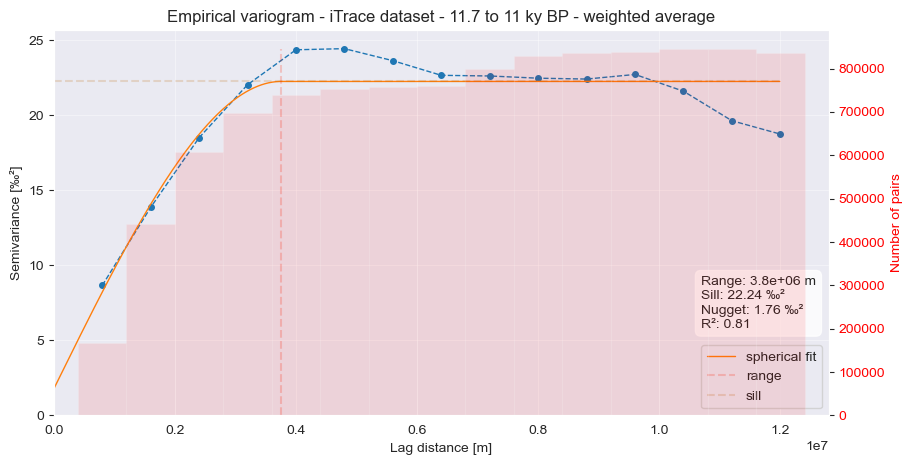

In [9]:
fig,ax = putils.plot_variogram_from_bins_and_gamma(centers=dict_dfs['i_all']['df']['lag'],
                                          gamma=dict_dfs['i_all']['df']['gamma'],
                                          time='iTrace dataset - 11.7 to 11 ky BP - weighted average',
                                          counts=itrace_variogram_df_all['count'],
                                          min_pairs=20,
                                          plot_model=True,
                                          model_name=model_name,
                                          model_fct=dict_dfs['i_all']['fct_fitted'],
                                          model_params=dict_dfs['i_all']['params'],
                                          figsize=(10,5),
                                        #   save_name='../output/variograms/fig_alltimes_multiple_linear_ele_lat_D_P_maxlag3e6_variogram_and_model_itrace.png'
                                          ) # type:ignore
plt.show()
plt.close('all')

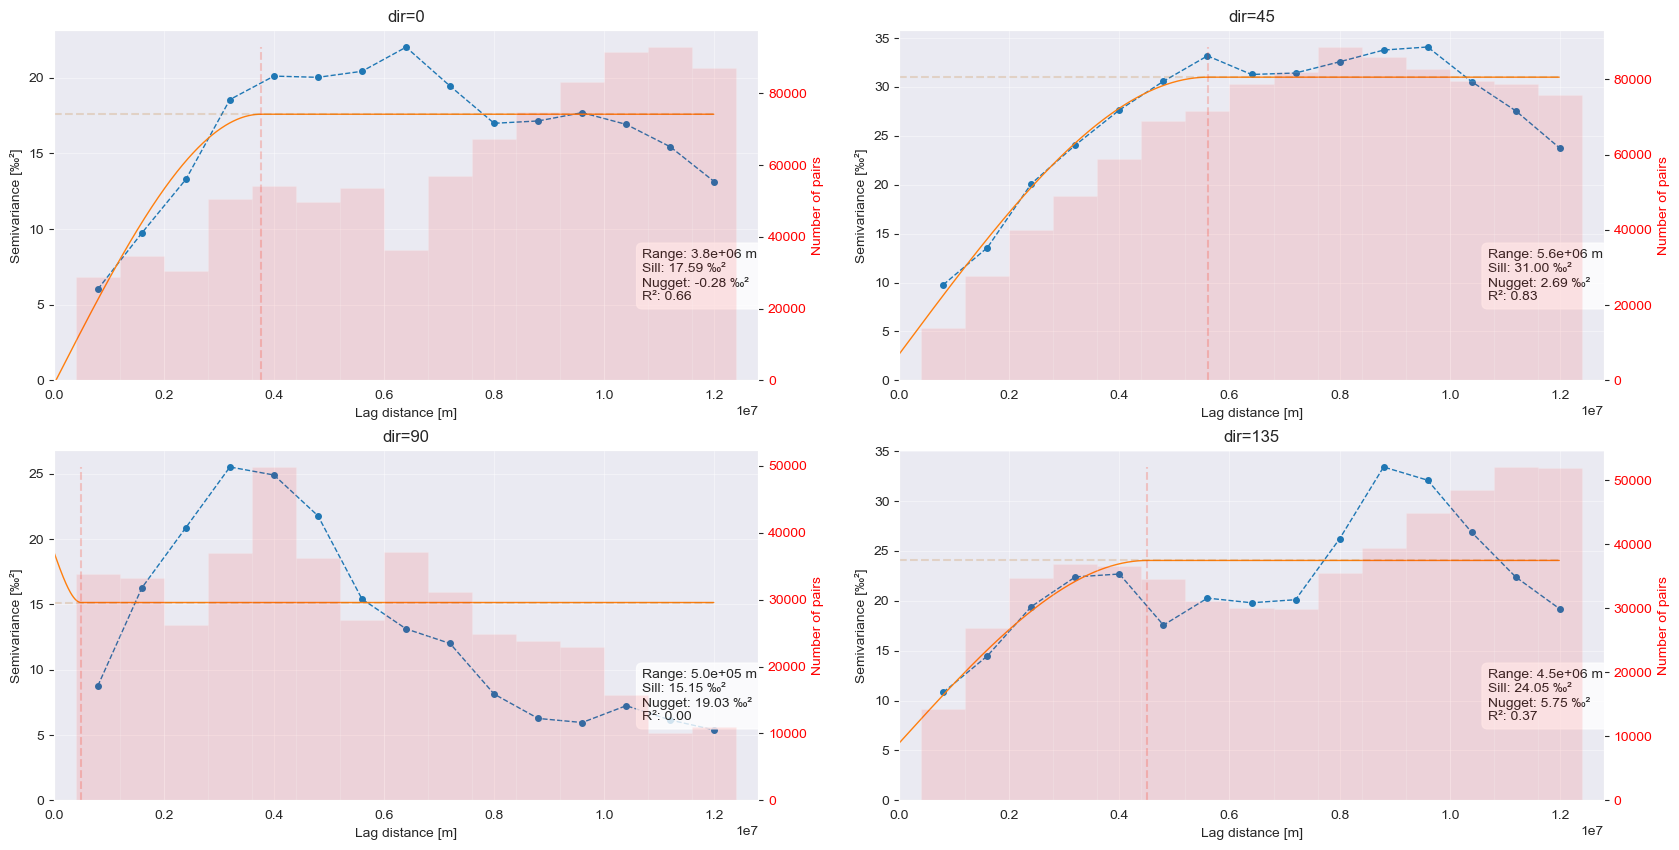

Range in direction 0°: 3763302.3033340876
Range in direction 45°: 5612244.318537927
Range in direction 90°: 495109.8408953417
Range in direction 135°: 4507874.137282741
Anisotropy Ratio: 11.335351986518615
Anisotropy Direction: 45°


In [10]:
list_dir = [0,45,90,135]
ranges=[]
fig,axes = plt.subplots(2,2,figsize=(20,10))
for i in range(2):
    for j in range(2):
        key = f'i_{list_dir[j+2*i]}'
        axes[i,j] = putils.plot_variogram_from_bins_and_gamma(centers=dict_dfs[key]['df']['lag'],
                                                            gamma=dict_dfs[key]['df']['gamma'],
                                                            time='iTrace dataset - 11.7 to 11 ky BP - weighted average',
                                                            counts=dict_dfs[key]['df']['count'],
                                                            min_pairs=20,
                                                            plot_model=True,
                                                            model_name=model_name,
                                                            model_fct=dict_dfs[key]['fct_fitted'],
                                                            model_params=dict_dfs[key]['params'],
                                                            figsize=(10,5),
                                                            ax_ = axes[i,j]
                                                            #     save_name='../output/variograms/fig_global_variogram_and_model_chen.png'
                                                            ) # type:ignore
        axes[i,j].set_title(f'dir={list_dir[j+2*i]}')
        ranges.append(dict_dfs[key]['params']['range'])
        
plt.show()
plt.close('all')

for dir, r in zip(list_dir, ranges):
    print(f'Range in direction {dir}°: {r}')
anisotropy_ratio = max(ranges) / min(ranges)
print(f'Anisotropy Ratio: {anisotropy_ratio}')
max_range_index = ranges.index(max(ranges))
print(f'Anisotropy Direction: {list_dir[max_range_index]}°')